# Chicago Crime Dataset — Initial Exploration
**CMPE 255 – Data Mining | Check-in 1**

Dataset: [Crimes – 2001 to Present](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2)  
Source: City of Chicago Open Data Portal  
API: Socrata Open Data API (SODA)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

pd.set_option('display.max_columns', None)

## 1. Load Data via SODA API
The full dataset has 8M+ rows. We pull a 50,000-row sample for initial exploration.

In [3]:
url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"
limit = 50000
params = {"$limit": limit, "$order": "date DESC"}

response = requests.get(url, params=params)
response.raise_for_status()
df = pd.DataFrame(response.json())
print(f"Loaded {len(df):,} rows")

Loaded 50,000 rows


## 2. Basic Shape & Column Overview

In [4]:
print(f"Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):\n{list(df.columns)}")

Shape: (50000, 22)

Columns (22):
['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']


In [5]:
df.dtypes

id                      object
case_number             object
date                    object
block                   object
iucr                    object
primary_type            object
description             object
location_description    object
arrest                    bool
domestic                  bool
beat                    object
district                object
ward                    object
community_area          object
fbi_code                object
x_coordinate            object
y_coordinate            object
year                    object
updated_on              object
latitude                object
longitude               object
location                object
dtype: object

In [6]:
df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14171090,JK222762,2026-04-18T00:00:00.000,002XX W NORTH AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,1814,018,2,7,14,1174063,1910985,2026,2026-04-25T15:43:40.000,41.911151209,-87.63598179,"{'latitude': '41.911151209', 'longitude': '-87..."
1,14172854,JK225054,2026-04-18T00:00:00.000,011XX S MICHIGAN AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,0123,001,4,32,06,1177422,1895476,2026,2026-04-25T15:43:40.000,41.868518128,-87.624113021,"{'latitude': '41.868518128', 'longitude': '-87..."
2,14170484,JK221977,2026-04-18T00:00:00.000,003XX N CENTRAL AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,False,True,1512,015,29,25,08B,1138977,1901868,2026,2026-04-25T15:43:40.000,41.886843497,-87.765098817,"{'latitude': '41.886843497', 'longitude': '-87..."
3,14171093,JK222668,2026-04-18T00:00:00.000,052XX W BLOOMINGDALE AVE,0710,THEFT,THEFT FROM MOTOR VEHICLE,STREET,False,False,2532,025,37,25,06,1141324,1911471,2026,2026-04-25T15:43:40.000,41.913152281,-87.756242665,"{'latitude': '41.913152281', 'longitude': '-87..."
4,14170493,JK221984,2026-04-18T00:00:00.000,001XX W ONTARIO ST,0460,BATTERY,SIMPLE,VEHICLE NON-COMMERCIAL,False,False,1832,018,42,8,08B,1175327,1904462,2026,2026-04-25T15:43:40.000,41.893223483,-87.63153437,"{'latitude': '41.893223483', 'longitude': '-87..."


## 3. Missing Values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df[missing_df['count'] > 0].sort_values('percent', ascending=False)

,count,percent
location_description,227,0.45
x_coordinate,72,0.14
y_coordinate,72,0.14
latitude,72,0.14
longitude,72,0.14
location,72,0.14


## 4. Target Variable — Arrest

In [8]:
df['arrest'].value_counts()

arrest
False    42399
True      7601
Name: count, dtype: int64

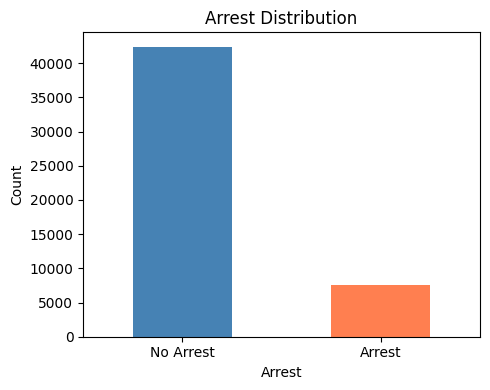

In [9]:
arrest_counts = df['arrest'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
arrest_counts.plot(kind='bar', color=['steelblue', 'coral'], ax=ax)
ax.set_title('Arrest Distribution')
ax.set_xlabel('Arrest')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Arrest', 'Arrest'], rotation=0)
plt.tight_layout()
plt.show()

## 5. Crime Types

In [10]:
print(f"Unique crime types: {df['primary_type'].nunique()}\n")
df['primary_type'].value_counts().head(15)

Unique crime types: 29



primary_type
THEFT                         10881
BATTERY                        9237
CRIMINAL DAMAGE                5383
ASSAULT                        4478
MOTOR VEHICLE THEFT            3956
OTHER OFFENSE                  3591
BURGLARY                       2969
DECEPTIVE PRACTICE             2807
NARCOTICS                      1520
CRIMINAL TRESPASS              1220
WEAPONS VIOLATION              1005
ROBBERY                         951
OFFENSE INVOLVING CHILDREN      367
CRIMINAL SEXUAL ASSAULT         343
SEX OFFENSE                     279
Name: count, dtype: int64

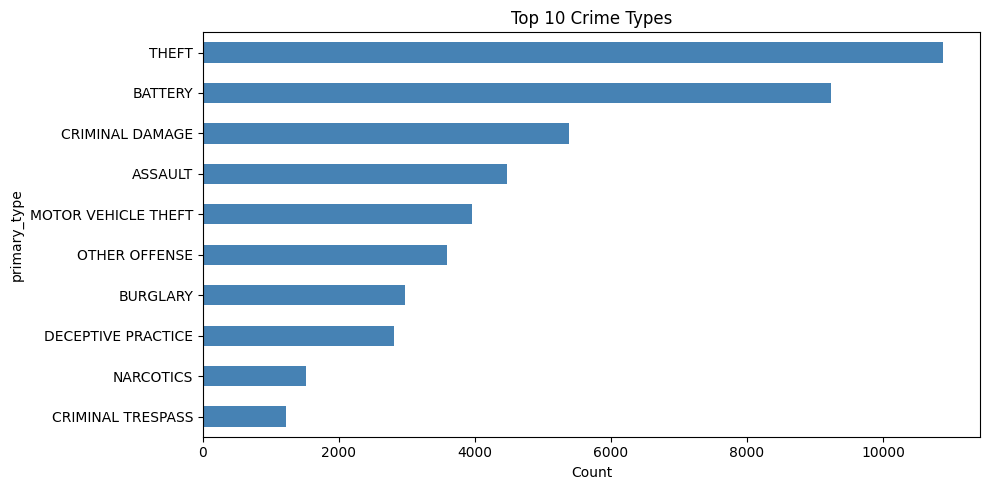

In [11]:
top_crimes = df['primary_type'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_crimes.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 10 Crime Types')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5b. Crime Types Over Time (by Year)

Year range: 2001 – 2026
Rows returned: 798


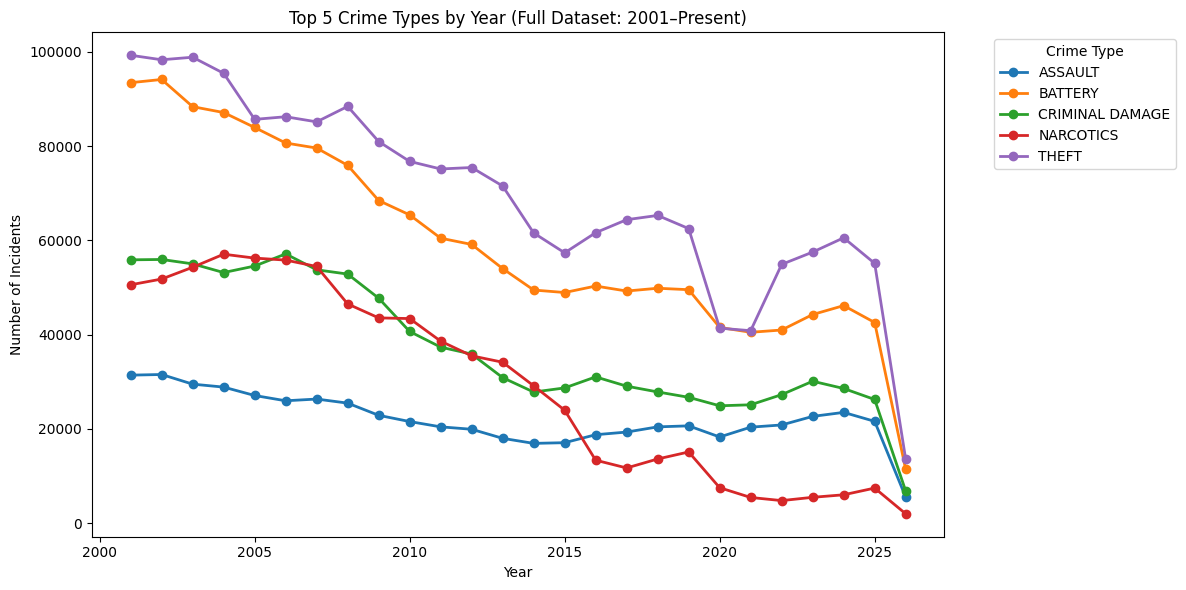

In [12]:
# Query the full dataset using server-side aggregation (no need to download 8M+ rows)
agg_url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"
agg_params = {
    "$select": "year, primary_type, count(*) as crime_count",
    "$group": "year, primary_type",
    "$order": "year, crime_count DESC",
    "$limit": 50000
}

agg_response = requests.get(agg_url, params=agg_params)
agg_response.raise_for_status()
df_agg = pd.DataFrame(agg_response.json())
df_agg['crime_count'] = df_agg['crime_count'].astype(int)
df_agg['year'] = df_agg['year'].astype(int)

print(f"Year range: {df_agg['year'].min()} – {df_agg['year'].max()}")
print(f"Rows returned: {len(df_agg):,}")

# Top 5 crime types overall
top5_overall = df_agg.groupby('primary_type')['crime_count'].sum().nlargest(5).index
df_top5 = df_agg[df_agg['primary_type'].isin(top5_overall)]

crime_by_year = df_top5.pivot_table(index='year', columns='primary_type', values='crime_count', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
crime_by_year.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Top 5 Crime Types by Year (Full Dataset: 2001–Present)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Temporal Features (extracted from Date)

In [13]:
df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month

print("Date range:", df['date'].min().date(), "to", df['date'].max().date())

Date range: 2026-01-22 to 2026-04-18


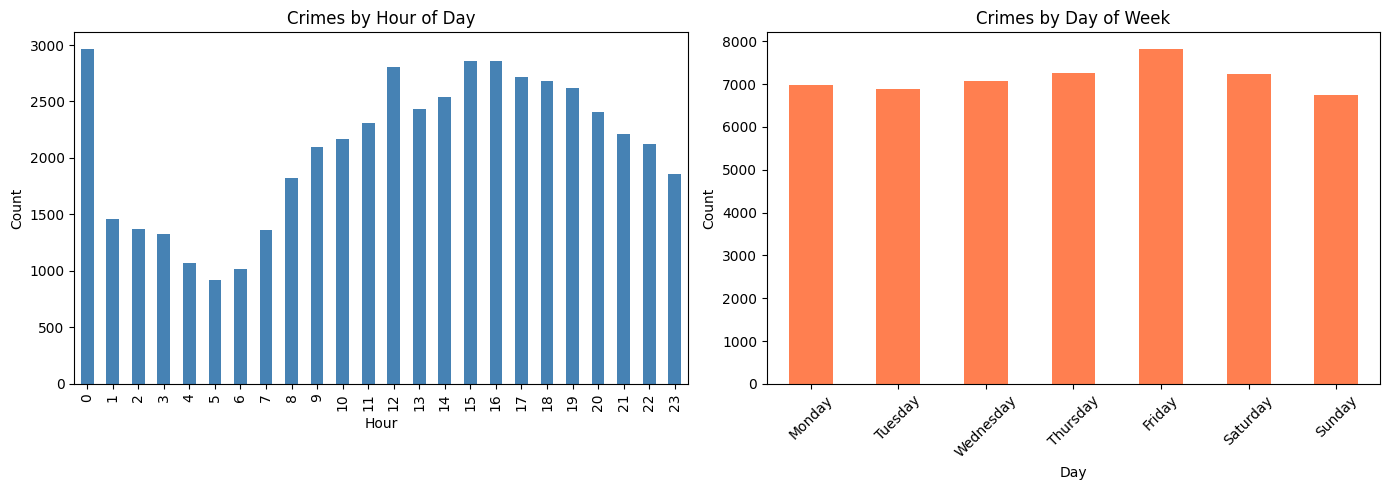

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Crimes by hour of day
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Crimes by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

# Crimes by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'].value_counts().reindex(day_order).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Crimes by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Geospatial Overview

Rows with valid coordinates: 49,928 / 50,000


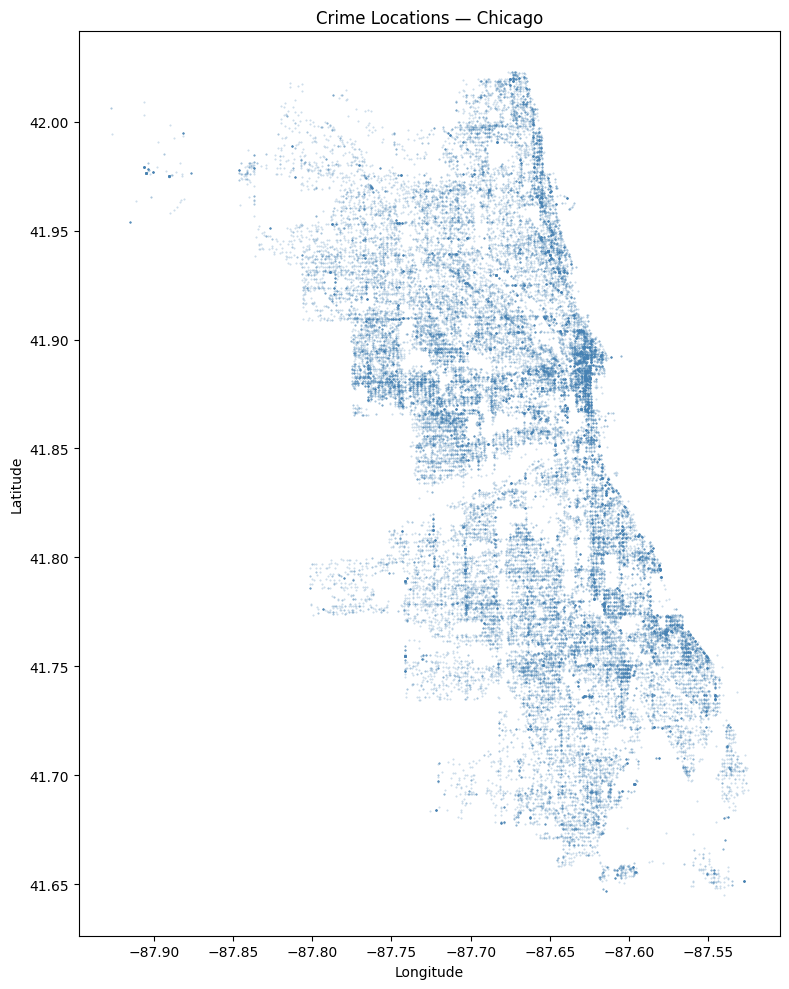

In [15]:
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

geo = df.dropna(subset=['latitude', 'longitude'])
print(f"Rows with valid coordinates: {len(geo):,} / {len(df):,}")

fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(geo['longitude'], geo['latitude'], s=0.2, alpha=0.3, c='steelblue')
ax.set_title('Crime Locations — Chicago')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 8. Arrest Rate by Crime Type

In [16]:
# arrest column comes as boolean from the API
df['arrest_binary'] = df['arrest'].astype(int)

arrest_by_type = (df.groupby('primary_type')['arrest_binary']
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'arrest_rate', 'count': 'total'})
                  .sort_values('arrest_rate', ascending=False))

# Only show types with at least 100 records
arrest_by_type[arrest_by_type['total'] >= 100].head(15)

,arrest_rate,total
primary_type,,
NARCOTICS,0.932895,1520
INTERFERENCE WITH PUBLIC OFFICER,0.872642,212
WEAPONS VIOLATION,0.754229,1005
PUBLIC PEACE VIOLATION,0.484733,262
CRIMINAL TRESPASS,0.354098,1220
BATTERY,0.180686,9237
OTHER OFFENSE,0.157338,3591
ASSAULT,0.125056,4478
THEFT,0.098888,10881


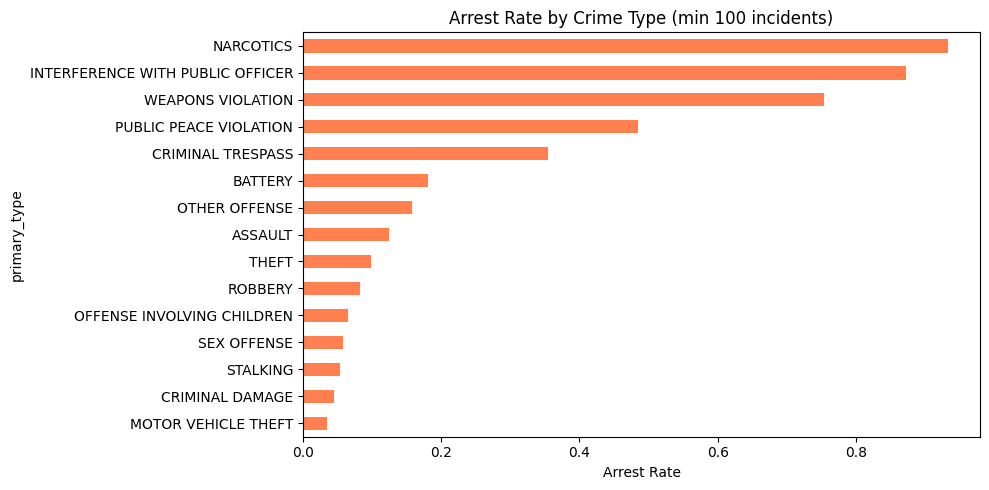

In [17]:
top = arrest_by_type[arrest_by_type['total'] >= 100].head(15)
fig, ax = plt.subplots(figsize=(10, 5))
top['arrest_rate'].plot(kind='barh', color='coral', ax=ax)
ax.set_title('Arrest Rate by Crime Type (min 100 incidents)')
ax.set_xlabel('Arrest Rate')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Arrest Rate by Hour of Day & Day of Week

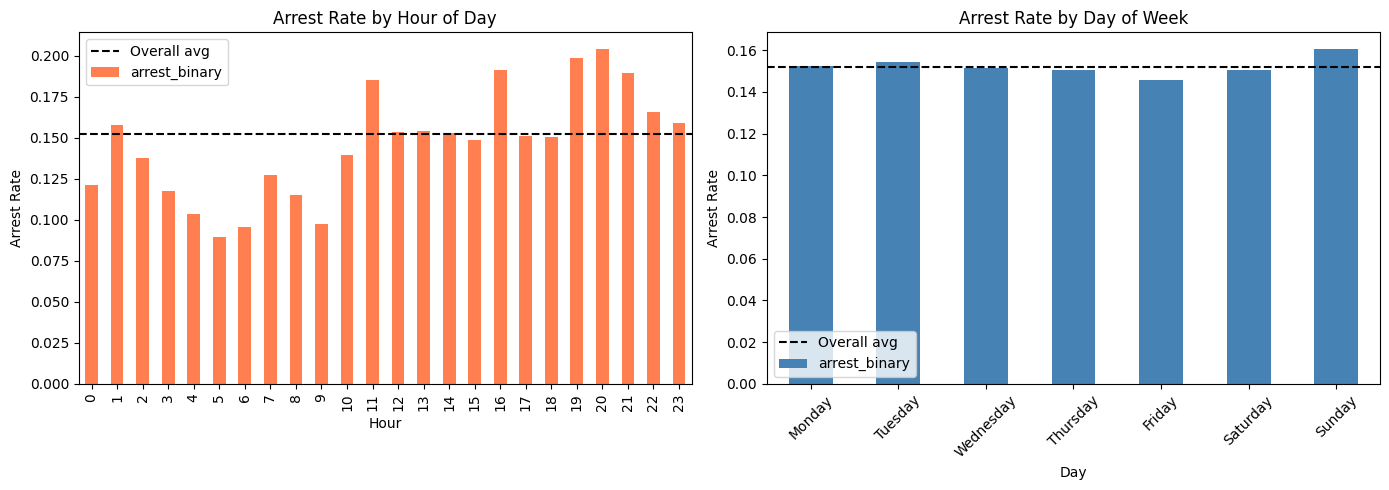

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Arrest rate by hour
arrest_by_hour = df.groupby('hour')['arrest_binary'].mean()
arrest_by_hour.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Arrest Rate by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Arrest Rate')
axes[0].axhline(y=df['arrest_binary'].mean(), color='black', linestyle='--', label='Overall avg')
axes[0].legend()

# Arrest rate by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
arrest_by_day = df.groupby('day_of_week')['arrest_binary'].mean().reindex(day_order)
arrest_by_day.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Arrest Rate by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Arrest Rate')
axes[1].axhline(y=df['arrest_binary'].mean(), color='black', linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Arrest Rate by District

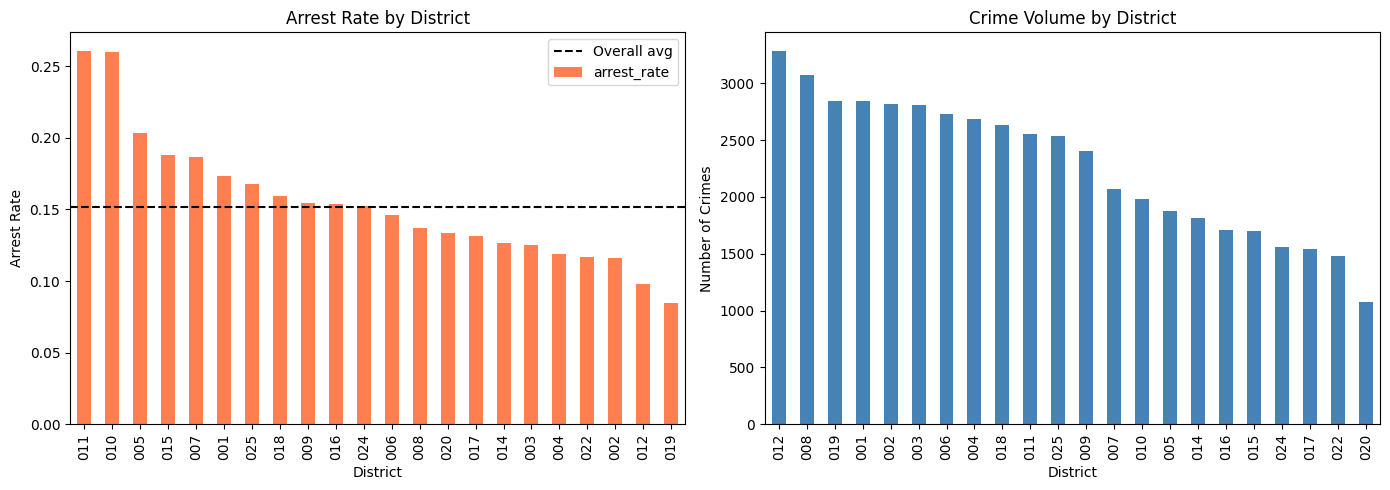


District with highest arrest rate: 011 (26.07%)
District with lowest arrest rate:  019 (8.43%)


In [20]:
arrest_by_district = (df.groupby('district')['arrest_binary']
                      .agg(['mean', 'count'])
                      .rename(columns={'mean': 'arrest_rate', 'count': 'total'})
                      .sort_values('arrest_rate', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Arrest rate by district
arrest_by_district['arrest_rate'].plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Arrest Rate by District')
axes[0].set_xlabel('District')
axes[0].set_ylabel('Arrest Rate')
axes[0].axhline(y=df['arrest_binary'].mean(), color='black', linestyle='--', label='Overall avg')
axes[0].legend()

# Crime volume by district
arrest_by_district.sort_values('total', ascending=False)['total'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Crime Volume by District')
axes[1].set_xlabel('District')
axes[1].set_ylabel('Number of Crimes')

plt.tight_layout()
plt.show()

print(f"\nDistrict with highest arrest rate: {arrest_by_district['arrest_rate'].idxmax()} ({arrest_by_district['arrest_rate'].max():.2%})")
print(f"District with lowest arrest rate:  {arrest_by_district['arrest_rate'].idxmin()} ({arrest_by_district['arrest_rate'].min():.2%})")

## 11. Feature Correlation Heatmap

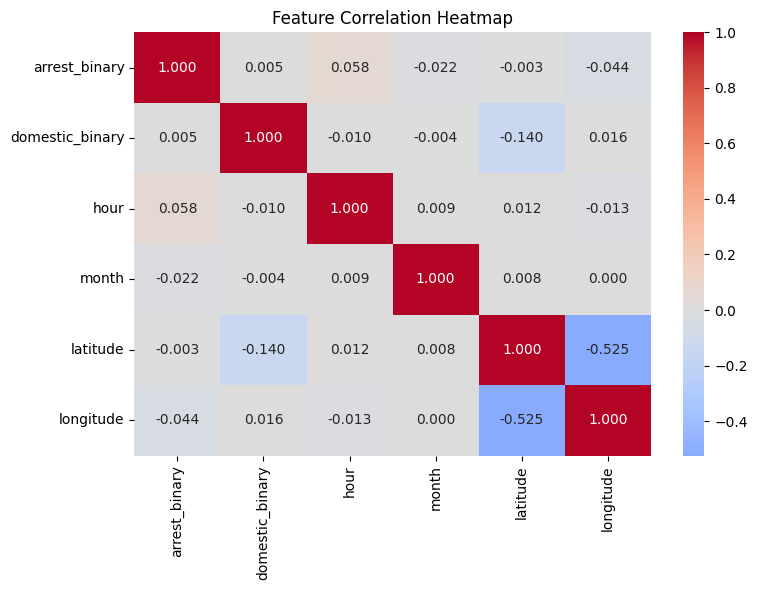

In [21]:
import seaborn as sns

# Select numeric/boolean features for correlation
df['domestic_binary'] = df['domestic'].astype(int)
numeric_cols = ['arrest_binary', 'domestic_binary', 'hour', 'month', 'latitude', 'longitude']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 9. Summary Statistics

In [18]:
print(f"Total records loaded:    {len(df):,}")
print(f"Date range:              {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique crime types:      {df['primary_type'].nunique()}")
print(f"Overall arrest rate:     {df['arrest_binary'].mean():.2%}")
print(f"Missing latitude/long:   {df['latitude'].isna().sum():,} ({df['latitude'].isna().mean():.2%})")
print(f"Unique districts:        {df['district'].nunique()}")
print(f"Unique community areas:  {df['community_area'].nunique()}")

Total records loaded:    50,000
Date range:              2026-01-22 to 2026-04-18
Unique crime types:      29
Overall arrest rate:     15.20%
Missing latitude/long:   72 (0.14%)
Unique districts:        22
Unique community areas:  77


## Key Observations

- **Class imbalance**: Arrests are likely the minority class — confirms we need SMOTE / class weighting.
- **Temporal patterns**: Crime volume varies by hour and day of week — supports extracting temporal features.
- **Geospatial coverage**: Coordinates available for most records — viable for DBSCAN hotspot clustering.
- **Crime type variety**: Many distinct types with different arrest rates — `primary_type` will be an important feature.

## Export Figures for Report

In [22]:
import os
import seaborn as sns

fig_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
fig_dir = "/Users/tanerscott/Library/Mobile Documents/com~apple~CloudDocs/Repos/LeetCode/Python Problems/SJSU/CMPE 255/Project/Check in 1/figures"
os.makedirs(fig_dir, exist_ok=True)

# --- Fig 1: Arrest Distribution ---
arrest_counts = df['arrest'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
arrest_counts.plot(kind='bar', color=['steelblue', 'coral'], ax=ax)
ax.set_title('Arrest Distribution')
ax.set_xlabel('Arrest')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Arrest', 'Arrest'], rotation=0)
plt.tight_layout()
fig.savefig(f'{fig_dir}/01_arrest_distribution.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Fig 2: Top 10 Crime Types ---
top_crimes = df['primary_type'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_crimes.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 10 Crime Types')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(f'{fig_dir}/02_top10_crime_types.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Fig 3: Top 5 Crime Types by Year (full dataset) ---
top5_overall = df_agg.groupby('primary_type')['crime_count'].sum().nlargest(5).index
df_top5 = df_agg[df_agg['primary_type'].isin(top5_overall)]
crime_by_year = df_top5.pivot_table(index='year', columns='primary_type', values='crime_count', fill_value=0)
fig, ax = plt.subplots(figsize=(12, 6))
crime_by_year.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Top 5 Crime Types by Year (Full Dataset: 2001–Present)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
fig.savefig(f'{fig_dir}/03_crime_types_by_year.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Fig 4: Crimes by Hour & Day of Week ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Crimes by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'].value_counts().reindex(day_order).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Crimes by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(f'{fig_dir}/04_crimes_by_hour_and_day.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Fig 5: Geospatial Scatter ---
geo = df.dropna(subset=['latitude', 'longitude'])
fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(geo['longitude'], geo['latitude'], s=0.2, alpha=0.3, c='steelblue')
ax.set_title('Crime Locations — Chicago')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
fig.savefig(f'{fig_dir}/05_geospatial_scatter.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Fig 6: Arrest Rate by Crime Type ---
top = arrest_by_type[arrest_by_type['total'] >= 100].head(15)
fig, ax = plt.subplots(figsize=(10, 5))
top['arrest_rate'].plot(kind='barh', color='coral', ax=ax)
ax.set_title('Arrest Rate by Crime Type (min 100 incidents)')
ax.set_xlabel('Arrest Rate')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(f'{fig_dir}/06_arrest_rate_by_crime_type.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Fig 7: Arrest Rate by Hour & Day ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
arrest_by_hour = df.groupby('hour')['arrest_binary'].mean()
arrest_by_hour.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Arrest Rate by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Arrest Rate')
axes[0].axhline(y=df['arrest_binary'].mean(), color='black', linestyle='--', label='Overall avg')
axes[0].legend()
arrest_by_day = df.groupby('day_of_week')['arrest_binary'].mean().reindex(day_order)
arrest_by_day.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Arrest Rate by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Arrest Rate')
axes[1].axhline(y=df['arrest_binary'].mean(), color='black', linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(f'{fig_dir}/07_arrest_rate_by_hour_and_day.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Fig 8: Arrest Rate & Volume by District ---
arrest_by_district = (df.groupby('district')['arrest_binary']
                      .agg(['mean', 'count'])
                      .rename(columns={'mean': 'arrest_rate', 'count': 'total'})
                      .sort_values('arrest_rate', ascending=False))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
arrest_by_district['arrest_rate'].plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Arrest Rate by District')
axes[0].set_xlabel('District')
axes[0].set_ylabel('Arrest Rate')
axes[0].axhline(y=df['arrest_binary'].mean(), color='black', linestyle='--', label='Overall avg')
axes[0].legend()
arrest_by_district.sort_values('total', ascending=False)['total'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Crime Volume by District')
axes[1].set_xlabel('District')
axes[1].set_ylabel('Number of Crimes')
plt.tight_layout()
fig.savefig(f'{fig_dir}/08_arrest_rate_by_district.png', dpi=150, bbox_inches='tight')
plt.close()

# --- Fig 9: Correlation Heatmap ---
numeric_cols = ['arrest_binary', 'domestic_binary', 'hour', 'month', 'latitude', 'longitude']
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
fig.savefig(f'{fig_dir}/09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()

print(f"All 9 figures saved to:\n{fig_dir}/")
for f in sorted(os.listdir(fig_dir)):
    print(f"  {f}")

All 9 figures saved to:
/Users/tanerscott/Library/Mobile Documents/com~apple~CloudDocs/Repos/LeetCode/Python Problems/SJSU/CMPE 255/Project/Check in 1/figures/
  01_arrest_distribution.png
  02_top10_crime_types.png
  03_crime_types_by_year.png
  04_crimes_by_hour_and_day.png
  05_geospatial_scatter.png
  06_arrest_rate_by_crime_type.png
  07_arrest_rate_by_hour_and_day.png
  08_arrest_rate_by_district.png
  09_correlation_heatmap.png
